I realy curious to know is there any correlation between boiling point and saturation indensity level of the odorants

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
ph_props_df = pd.read_csv('data/pubchem_physical_props_cache.csv')
ph_props_df.head()

,CID,boiling_point_c,vapor_pressure_mmhg,error
0,179,147.500,2.690,NaN
1,240,178.889,1.270,NaN
2,244,205.500,0.094,NaN
3,323,299.000,0.001,NaN
4,326,235.500,NaN,NaN


In [14]:
bp_df = ph_props_df[['CID', 'boiling_point_c']].dropna()
bp_df.shape

(192, 2)

In [17]:
data_df = pd.read_csv('data/waka_dragon_merged.csv')
data_df.head()

,Unnamed: 0.1,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di_x,intensity_class,MW,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,12,12,179,513-86-0,acetoin,49.69,0.90,0.76,1,88.12,...,54.205,92.70,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0.0
1,40,40,240,100-52-7,benzaldehyde,62.02,1.23,0.69,1,106.13,...,62.810,104.63,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0.0
2,42,42,244,100-51-6,benzyl alcohol,30.28,1.49,0.33,0,108.15,...,65.737,107.27,0.866,-2.74,-2.83,-2.82,1.0,34.0,0.000,0.0
3,89,89,323,91-64-5,coumarin,26.79,0.68,0.77,0,146.15,...,75.670,133.02,0.984,-3.32,-3.47,-3.49,3.0,56.0,0.000,0.0
4,90,90,326,122-03-2,cumin aldehyde,49.53,1.29,0.47,1,148.22,...,91.587,156.53,0.898,-3.70,-3.91,-3.95,1.0,50.0,0.033,0.0


In [19]:
bp_df_merged = pd.merge(
    bp_df,
    data_df[['Name', 'CID', 'Imax']],
    left_on='CID',
    right_on='CID',
    how='left'
)
bp_df_merged.head()


,CID,boiling_point_c,Name,Imax
0,179,147.500,acetoin,49.69
1,240,178.889,benzaldehyde,62.02
2,244,205.500,benzyl alcohol,30.28
3,323,299.000,coumarin,26.79
4,326,235.500,cumin aldehyde,49.53


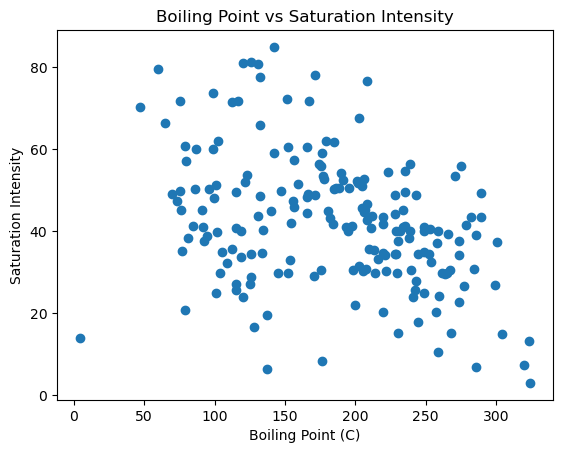

In [21]:
pair = bp_df_merged[['boiling_point_c', 'Imax']].dropna()
r_pearson = pair['boiling_point_c'].corr(pair['Imax'], method='pearson')
r_spearman = pair['boiling_point_c'].corr(pair['Imax'], method='spearman')
print(f"n (pairs with both values): {len(pair)}")
print(f"Pearson r:  {r_pearson:.4f}")
print(f"Spearman rho: {r_spearman:.4f}")

plt.scatter(pair['boiling_point_c'], pair['Imax'], alpha=0.7)
plt.xlabel('Boiling Point (C)')
plt.ylabel('Saturation Intensity')
plt.title(
    f'Boiling Point vs Saturation Intensity\n'
    f'Pearson r = {r_pearson:.3f}, Spearman ρ = {r_spearman:.3f} (n = {len(pair)})'
)
plt.tight_layout()
plt.show()